# ConvNext with Entropy Filtering and Ordinal Loss

This notebook trains an ConvNext model with:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)

In [1]:
from torch import optim
from torchvision.models import convnext_small, ConvNeXt_Small_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../../')
from utils.dataset import PandasDataset

## Configuration

In [ ]:
# Training parameters
seed = 42
batch_size = 10
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.2
patience = 7

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/convnext_small.pth'
log_path = 'logs/convnext_small.txt'

Using device: cuda


## Ordinal Loss Function

Ordinal regression treats the problem as a series of binary classifications:
- For ISUP grade k, we predict k binary labels: [1,1,...,1,0,0,...,0]
- Example: ISUP 2 → [1, 1, 0, 0, 0] (grade > 0, grade > 1, but not > 2, > 3, > 4)

In [3]:
from torch.nn import functional as F

class FocalOrdinalRegressionLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=1.0, gamma=2.0):
        """
        alpha : peso da focal loss na loss total
        beta  : peso da ordinal loss na loss total
        gamma : fator de modulação do focal loss
        """
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def focal_loss(self, logits, targets):
        probs = torch.sigmoid(logits)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = probs * targets + (1 - probs) * (1 - targets)
        modulation = (1 - p_t) ** self.gamma
        return (modulation * bce).mean()

    def forward(self, logits, targets):
        targets = targets.to(logits.device)

        f_loss = self.focal_loss(logits, targets)

        probs = torch.sigmoid(logits)
        expected_class = torch.sum(probs, dim=1)
        targets_class = torch.sum(targets, dim=1)
        max_class = logits.shape[1]
        ordinal_loss = torch.mean((expected_class - targets_class) ** 2) / (max_class ** 2)

        return self.alpha * f_loss + self.beta * ordinal_loss


loss_function = FocalOrdinalRegressionLoss(
    alpha=0.5,
    beta=0.5,
    gamma=0.2,
).to(device)



def decode_ordinal_predictions(logits):
    """
    Converte predições ordinais em labels de classe.

    Args:
        logits: (batch_size, num_classes) - saídas brutas do modelo

    Returns:
        ISUP grades preditos (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

## Load Data with Entropy Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

print(df_entropy_sorted.head())
n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)

# Maneira Correta
print("max_entropy", df_entropy_top["isup_grade"].value_counts())
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
                           image_id data_provider  isup_grade gleason_score  \
0  e0f8b96960ada384a00e493545f783da       radboud           5           5+5   
1  c3f6dfc5c801b1f2aed4c9e318bd015d       radboud           5           5+5   
2  35c7912e941c9bf21594deeda6c891e2       radboud           3           4+3   
3  a4514f8a6800bf122ae746c4f573ee6f       radboud           5           5+5   
4  0a8c2bda6e00a040372185ccd9a3c4ab    karolinska           5           4+5   

   fold             image_id_from_results  true_label  pred_b0  entropy_b0  \
0     1  e0f8b96960ada384a00e493545f783da         5.0      3.0    0.646624   
1     2  c3f6dfc5c801b1f2aed4c9e318bd015d         5.0      0.0    0.114379   
2     0  35c7912e941c9bf21594deeda6c891e2         3.0      4.0         NaN   
3     0  a4514f8a6800bf122ae746c4f573ee6f         5.0      4.0    0.327839   
4     0  0a8c2bda6e00a040372185ccd9a3c4ab         5.0      4.0    0.319212  

## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
    Albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
])

# No augmentation for validation/test
val_transforms = Albu.Compose([
    Albu.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset),
    pin_memory=True,
    persistent_workers=True

)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset),
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
    persistent_workers=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup

In [7]:
from utils.models import ConvNeXtApi

# Load pre-trained EfficientNet-B0
load_model = convnext_small(weights=ConvNeXt_Small_Weights.DEFAULT)
model = ConvNeXtApi(model=load_model, output_dimensions=output_classes, dropout_rate=0.2)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.2


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

scaler = torch.amp.GradScaler()

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn, accumulation_steps=8):
    model.train()
    train_loss = []
    running_loss = 0.0
    smooth_loss = 0.0

    bar_progress = tqdm(dataloader, desc="Training", dynamic_ncols=True)
    optimizer.zero_grad()

    for step, (batch_data, batch_targets, _) in enumerate(bar_progress):
        # non_blocking=True: transferência assíncrona (requer pin_memory=True no DataLoader)
        batch_data = batch_data.to(device, non_blocking=True)
        batch_targets = batch_targets.to(device, non_blocking=True)

        with torch.autocast(device_type='cuda', dtype=torch.float16):  # Mixed precision
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets) / accumulation_steps

        scaler.scale(loss).backward()

        if (step + 1) % accumulation_steps == 0 or (step + 1) == len(dataloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        # Mantém tudo em tensor — sem .numpy() dentro do loop
        loss_val = loss.detach() * accumulation_steps
        running_loss += loss_val.item()  # .item() só quando necessário pro log
        train_loss.append(loss_val.item())

        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)

        # Atualiza display a cada 10 steps para reduzir I/O
        if step % 10 == 0:
            bar_progress.set_postfix({
                'loss': f'{train_loss[-1]:.5f}',
                'smooth': f'{smooth_loss:.5f}'
            })

    return train_loss


def validation_step(model, dataloader, device, loss_fn):
    model.eval()

    total_loss = 0.0
    num_batches = 0
    all_preds = []
    all_targets = []

    bar_progress = tqdm(dataloader, desc="Validation", dynamic_ncols=True)

    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device, non_blocking=True)
            batch_targets_ordinal = batch_targets.to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(batch_data)
                loss = loss_fn(logits, batch_targets_ordinal)

            probs = torch.sigmoid(logits)
            predictions = (probs > 0.5).sum(dim=1)
            targets_class = batch_targets.sum(dim=1).long()

            # Acumula em tensores na CPU — sem conversão prematura
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class.cpu())

            total_loss += loss.item()
            num_batches += 1

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return {
        'val_loss': total_loss / num_batches,
        'val_acc': accuracy_score(all_targets, all_preds),
        'val_kappa': cohen_kappa_score(all_targets, all_preds, weights='quadratic'),
        'val_f1': f1_score(all_targets, all_preds, average='macro', zero_division=0),
        'val_recall': recall_score(all_targets, all_preds, average='macro', zero_division=0),
        'val_precision': precision_score(all_targets, all_preds, average='macro', zero_division=0),
    }

## Training Loop

In [ ]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  ✓ Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training...


Epoch 1/50
--------------------------------------------------------------------------------


Training:   1%|▏         | 30/2358 [00:16<20:49,  1.86it/s, loss=0.35476, smooth=0.38054] 


KeyboardInterrupt: 

: 

## Plot Training History

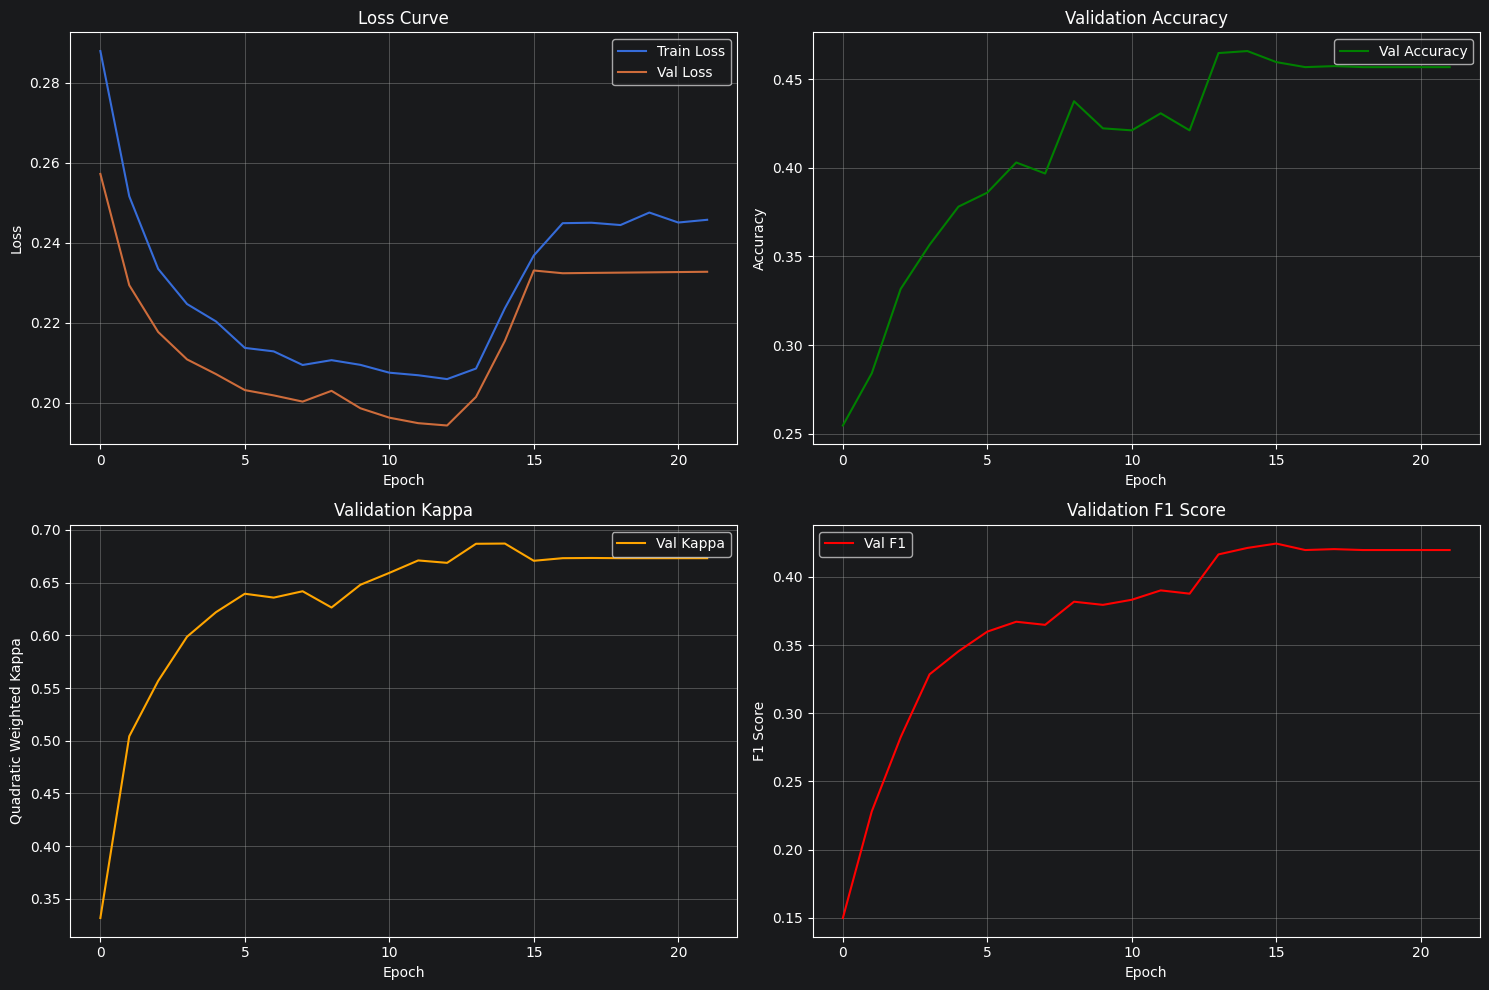

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

In [ ]:
from utils.metrics import evaluation, format_metrics

# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt
#
# # Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
# model.eval()
#
# # Evaluate on test set
# test_preds = []
# test_targets = []
#
# print("Evaluating on test set...\n")
#
# with torch.no_grad():
#     for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
#         batch_data = batch_data.to(device)
#
#         # Forward pass
#         logits = model(batch_data)
#
#         # Decode predictions
#         predictions = decode_ordinal_predictions(logits)
#
#         # Convert ordinal targets to class labels
#         targets_class = batch_targets.sum(dim=1).long()
#
#         test_preds.append(predictions.cpu())
#         test_targets.append(targets_class)
#
# # Concatenate results
# test_preds = torch.cat(test_preds).numpy()
# test_targets = torch.cat(test_targets).numpy()
#
# # Calculate metrics
# test_accuracy = accuracy_score(test_targets, test_preds)
# test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
# test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)
#
# print("\n" + "="*80)
# print("TEST SET RESULTS")
# print("="*80)
# print(f"Accuracy: {test_accuracy*100:.2f}%")
# print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
# print(f"Macro F1 Score: {test_f1:.4f}")
# print("="*80)
#
# # Classification report
# print("\nClassification Report:")
# print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
#
# # Confusion matrix
# cm = confusion_matrix(test_targets, test_preds)
# print("\nConfusion Matrix:")
# print(cm)
#
# # Plot confusion matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=[f'ISUP {i}' for i in range(6)],
#     yticklabels=[f'ISUP {i}' for i in range(6)],
#     cbar_kws={'label': 'Count'}
# )
# plt.title('Confusion Matrix - Test Set (Ordinal Loss)', fontsize=14, fontweight='bold')
# plt.ylabel('True Label', fontsize=12)
# plt.xlabel('Predicted Label', fontsize=12)
# plt.tight_layout()
# plt.savefig('logs/b0-entropy-ordinal-confusion-matrix.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # Save test results
# with open('../logs/b0-entropy-ordinal-test-results.txt', 'w') as f:
#     f.write("EfficientNet-B0 with Entropy Filtering and Ordinal Loss\n")
#     f.write("="*80 + "\n\n")
#     f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
#     f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
#     f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
#     f.write("Classification Report:\n")
#     f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
#     f.write("\nConfusion Matrix:\n")
#     f.write(str(cm))
#
# print("\nTest results saved to logs/b0-entropy-ordinal-test-results.txt")
response = evaluation(model, test_loader, device)
result = format_metrics(response[0])
print("\n=== TEST RESULTS (ENTROPY ORDINAL=2.0) ===")
print(result)

100%|██████████| 530/530 [05:52<00:00,  1.51it/s]



=== TEST RESULTS (ENTROPY ORDINAL=2.0) ===
VAL_ACC      Mean: 0.242 | Std: 0.011 | 95% CI: [0.225, 0.259]
VAL_KAPPA    Mean: 0.558 | Std: 0.014 | 95% CI: [0.534, 0.581]
VAL_F1       Mean: 0.230 | Std: 0.011 | 95% CI: [0.213, 0.248]
VAL_RECALL   Mean: 0.275 | Std: 0.011 | 95% CI: [0.256, 0.294]
VAL_PRECISION Mean: 0.446 | Std: 0.042 | 95% CI: [0.306, 0.479]
MEAN_ERROR   Mean: 1.089 | Std: 0.021 | 95% CI: [1.054, 1.122]


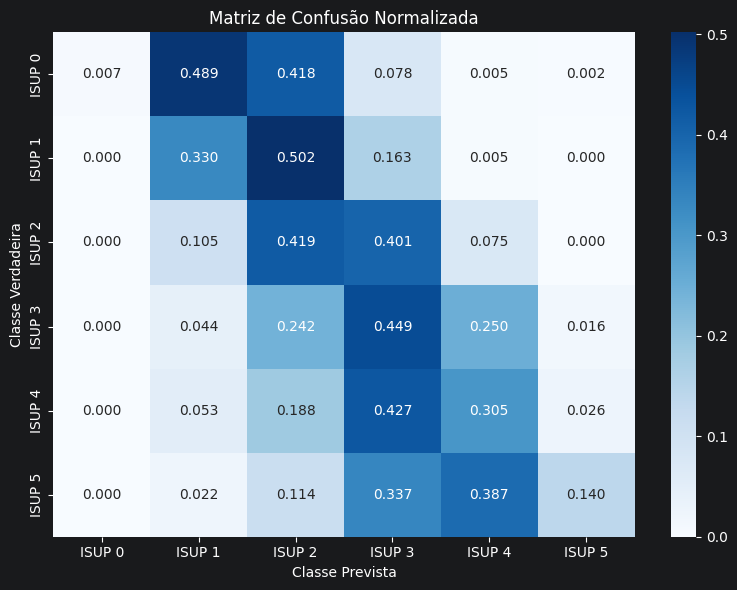

In [ ]:
cm = response[0].get("confusion_matrix")
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalização por linha (cada linha soma 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels das classes (ajuste conforme necessário)
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Matriz de Confusão Normalizada")
plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary

This notebook trained EfficientNet-B0 with:
1. **Entropy filtering** - Removed high-entropy samples for cleaner training data
2. **Ordinal loss** - Leveraged the ordered nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)

The ordinal approach enforces the constraint that predictions should respect the natural ordering of grades, potentially improving performance on ordinal classification tasks like cancer grading.